# Back-propagation Capstone

In [1]:
import numpy as np
import torch, torch.nn as nn
import matplotlib.pyplot as plt

!wget -O fun.py https://raw.githubusercontent.com/omR2/ThePythonQuants/main/TheAIEngineer/fun.py
%run -i fun.py

d = 2 # input dimension
h = 2 # hidden dimension
myPars = {'x': [1,-1.],
          'W1': [[1., -2.], [0.5, 1.]],
          'b1': [0., 0.],
          'W2': [[1., -1.]],
          'b2': [0.],
          'y': 2.,
          'lr': 0.01
          }

--2026-06-14 23:20:46--  https://raw.githubusercontent.com/omR2/ThePythonQuants/main/TheAIEngineer/fun.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.108.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 13866 (14K) [text/plain]
Saving to: ‘fun.py’

fun.py              100%[===================>]  13.54K  --.-KB/s    in 0.001s  

2026-06-14 23:20:46 (19.2 MB/s) - ‘fun.py’ saved [13866/13866]



# Forward Implementation (using identical parameters)
* MyMLPForward accomodates ReLU or sigmoid activation functions,
  NumPy or Torch (with requires_grad either True or False)
* Class TinyMLP contains a forward() method using ReLU and Torch


In [2]:
z0 = TinyMLP(d, h, myPars).forward()

z1 = myMLPForward(myPars, bSigmoid = False, bTorch = 1) #Torch(requires_grad = True), ReLU
z2 = myMLPForward(myPars, bSigmoid = False, bTorch = -1) #Torch(requires_grad = False), ReLU
z3 = myMLPForward(myPars, bSigmoid = False, bTorch = 0) #Numpy, ReLU

z4 = myMLPForward(myPars, bSigmoid = True, bTorch = 1) #Torch(requires_grad = True), Sigmoid
z5 = myMLPForward(myPars, bSigmoid = True, bTorch = -1) #Torch(requires_grad = False), Sigmoid
z6 = myMLPForward(myPars, bSigmoid = True, bTorch = 0) #Numpy, Sigmoid

z0,z1,z2,z3

/content/fun.py:63: UserWarning: The use of `x.T` on tensors of dimension other than 2 to reverse their shape is deprecated and it will throw an error in a future release. Consider `x.mT` to transpose batches of matrices or `x.permute(*torch.arange(x.ndim - 1, -1, -1))` to reverse the dimensions of a tensor. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4480.)
  x = torch.tensor(x_in, dtype=torch.float32).clone().T


({'f': tensor([3.], grad_fn=<AddBackward0>),
  'bSigmoid': False,
  'bTorch': True,
  'Theta': {'x': Parameter containing:
   tensor([ 1., -1.], requires_grad=True),
   'W1': Parameter containing:
   tensor([[ 1.0000, -2.0000],
           [ 0.5000,  1.0000]], requires_grad=True),
   'b1': Parameter containing:
   tensor([0., 0.], requires_grad=True),
   'W2': Parameter containing:
   tensor([[ 1., -1.]], requires_grad=True),
   'b2': Parameter containing:
   tensor(0., requires_grad=True)},
  'a1': tensor([ 3.0000, -0.5000], grad_fn=<AddBackward0>),
  'h1': tensor([3., 0.], grad_fn=<ReluBackward0>),
  'y': Parameter containing:
  tensor(2., requires_grad=True),
  'lr': Parameter containing:
  tensor(0.0100, requires_grad=True)},
 {'f': tensor([3.], grad_fn=<AddBackward0>),
  'bSigmoid': False,
  'bTorch': 1,
  'Theta': {'x': tensor([ 1., -1.]),
   'W1': tensor([[ 1.0000, -2.0000],
           [ 0.5000,  1.0000]], requires_grad=True),
   'b1': tensor([0., 0.], requires_grad=True),
   'W2

# Backward Implementation (inheriting parameters)
* MyMLPBackward also accomodates ReLU or sigmoid activation functions, NumPy or Torch (with requires_grad either True or False)
* myBuiltIn is a compact front to back reimplementation

In [3]:
Z0 = myMLPBackward(z0.copy())

Z1 = myMLPBackward(z2.copy()) #Torch(requires_grad = True), ReLU
Z2 = myMLPBackward(z3.copy()) #Torch(requires_grad = False), ReLU
Z3 = myMLPBackward(z1.copy()) #Numpy, ReLU

Z4 = myMLPBackward(z5.copy()) #Torch(requires_grad = True), Sigmoid
Z5 = myMLPBackward(z6.copy()) #Torch(requires_grad = False), Sigmoid
Z6 = myMLPBackward(z4.copy()) #Numpy, Sigmoid

reModel = myBuiltIn(d, h, myPars)

Z0, Z1, Z2, Z3

/content/fun.py:8: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  return 1 / (1 + np.exp(-x))


({'f': tensor([3.], grad_fn=<AddBackward0>),
  'bSigmoid': False,
  'bTorch': True,
  'Theta': {'x': Parameter containing:
   tensor([ 1., -1.], requires_grad=True),
   'W1': Parameter containing:
   tensor([[ 0.9900, -1.9900],
           [ 0.5000,  1.0000]], requires_grad=True),
   'b1': Parameter containing:
   tensor([-0.0100,  0.0000], requires_grad=True),
   'W2': Parameter containing:
   tensor([[ 0.9700, -1.0000]], requires_grad=True),
   'b2': Parameter containing:
   tensor(-0.0100, requires_grad=True)},
  'a1': tensor([ 3.0000, -0.5000], grad_fn=<AddBackward0>),
  'h1': tensor([3., 0.], grad_fn=<ReluBackward0>),
  'y': Parameter containing:
  tensor(2., requires_grad=True),
  'lr': Parameter containing:
  tensor(0.0100, requires_grad=True),
  'grad_norms': {'W1': 1.4142135381698608, 'b1': 1.0, 'W2': 3.0, 'b2': 1.0}},
 {'f': tensor([3.]),
  'bSigmoid': False,
  'bTorch': -1,
  'Theta': {'x': tensor([ 1., -1.]),
   'W1': tensor([[ 0.9900, -1.9900],
           [ 0.5000,  1.0000]

In [4]:
num_iterations = 100

results_nn_sequential_relu = run_sequential_training_simulation(
    num_iterations=num_iterations,
    d=d, h=h, initial_pars=myPars, model = reModel
)

# Run simulation for NumPy (ReLU)
results_numpy_relu = run_training_simulation(
    num_iterations=num_iterations,
    d=d, h=h, initial_pars=myPars, bSigmoid=False, bTorch_mode=0
)

# Run simulation for PyTorch without autograd (ReLU)
results_torch_no_grad_relu = run_training_simulation(
    num_iterations=num_iterations,
    d=d, h=h, initial_pars=myPars, bSigmoid=False, bTorch_mode=-1
)

# Run simulation for PyTorch with autograd (ReLU)
results_torch_autograd_relu = run_training_simulation(
    num_iterations=num_iterations,
    d=d, h=h, initial_pars=myPars, bSigmoid=False, bTorch_mode=1
)

# Run simulation for TinyMLP (uses autograd and ReLU internally)
results_tinymlp = run_training_simulation(
    num_iterations=num_iterations,
    d=d, h=h, initial_pars=myPars, bSigmoid=False, bTorch_mode=2
)

# Run simulation for NumPy (Sigmoid)
results_numpy_sigmoid = run_training_simulation(
    num_iterations=num_iterations,
    d=d, h=h, initial_pars=myPars, bSigmoid=True, bTorch_mode=0
)

# Run simulation for PyTorch without autograd (Sigmoid)
results_torch_no_grad_sigmoid = run_training_simulation(
    num_iterations=num_iterations,
    d=d, h=h, initial_pars=myPars, bSigmoid=True, bTorch_mode=-1
)

# Run simulation for PyTorch with autograd (Sigmoid)
results_torch_autograd_sigmoid = run_training_simulation(
    num_iterations=num_iterations,
    d=d, h=h, initial_pars=myPars, bSigmoid=True, bTorch_mode=1
)

/content/fun.py:63: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x = torch.tensor(x_in, dtype=torch.float32).clone().T
/content/fun.py:64: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  W1 = torch.tensor(W1_in, dtype=torch.float32).clone().requires_grad_(bTorch==1)
/content/fun.py:65: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  b1 = torch.tensor(b1_in, dtype=torch.float32).clone().requires_grad_(bTorch==1)
/content/fun.py:66: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTe

Plotting Combined ReLU Results:


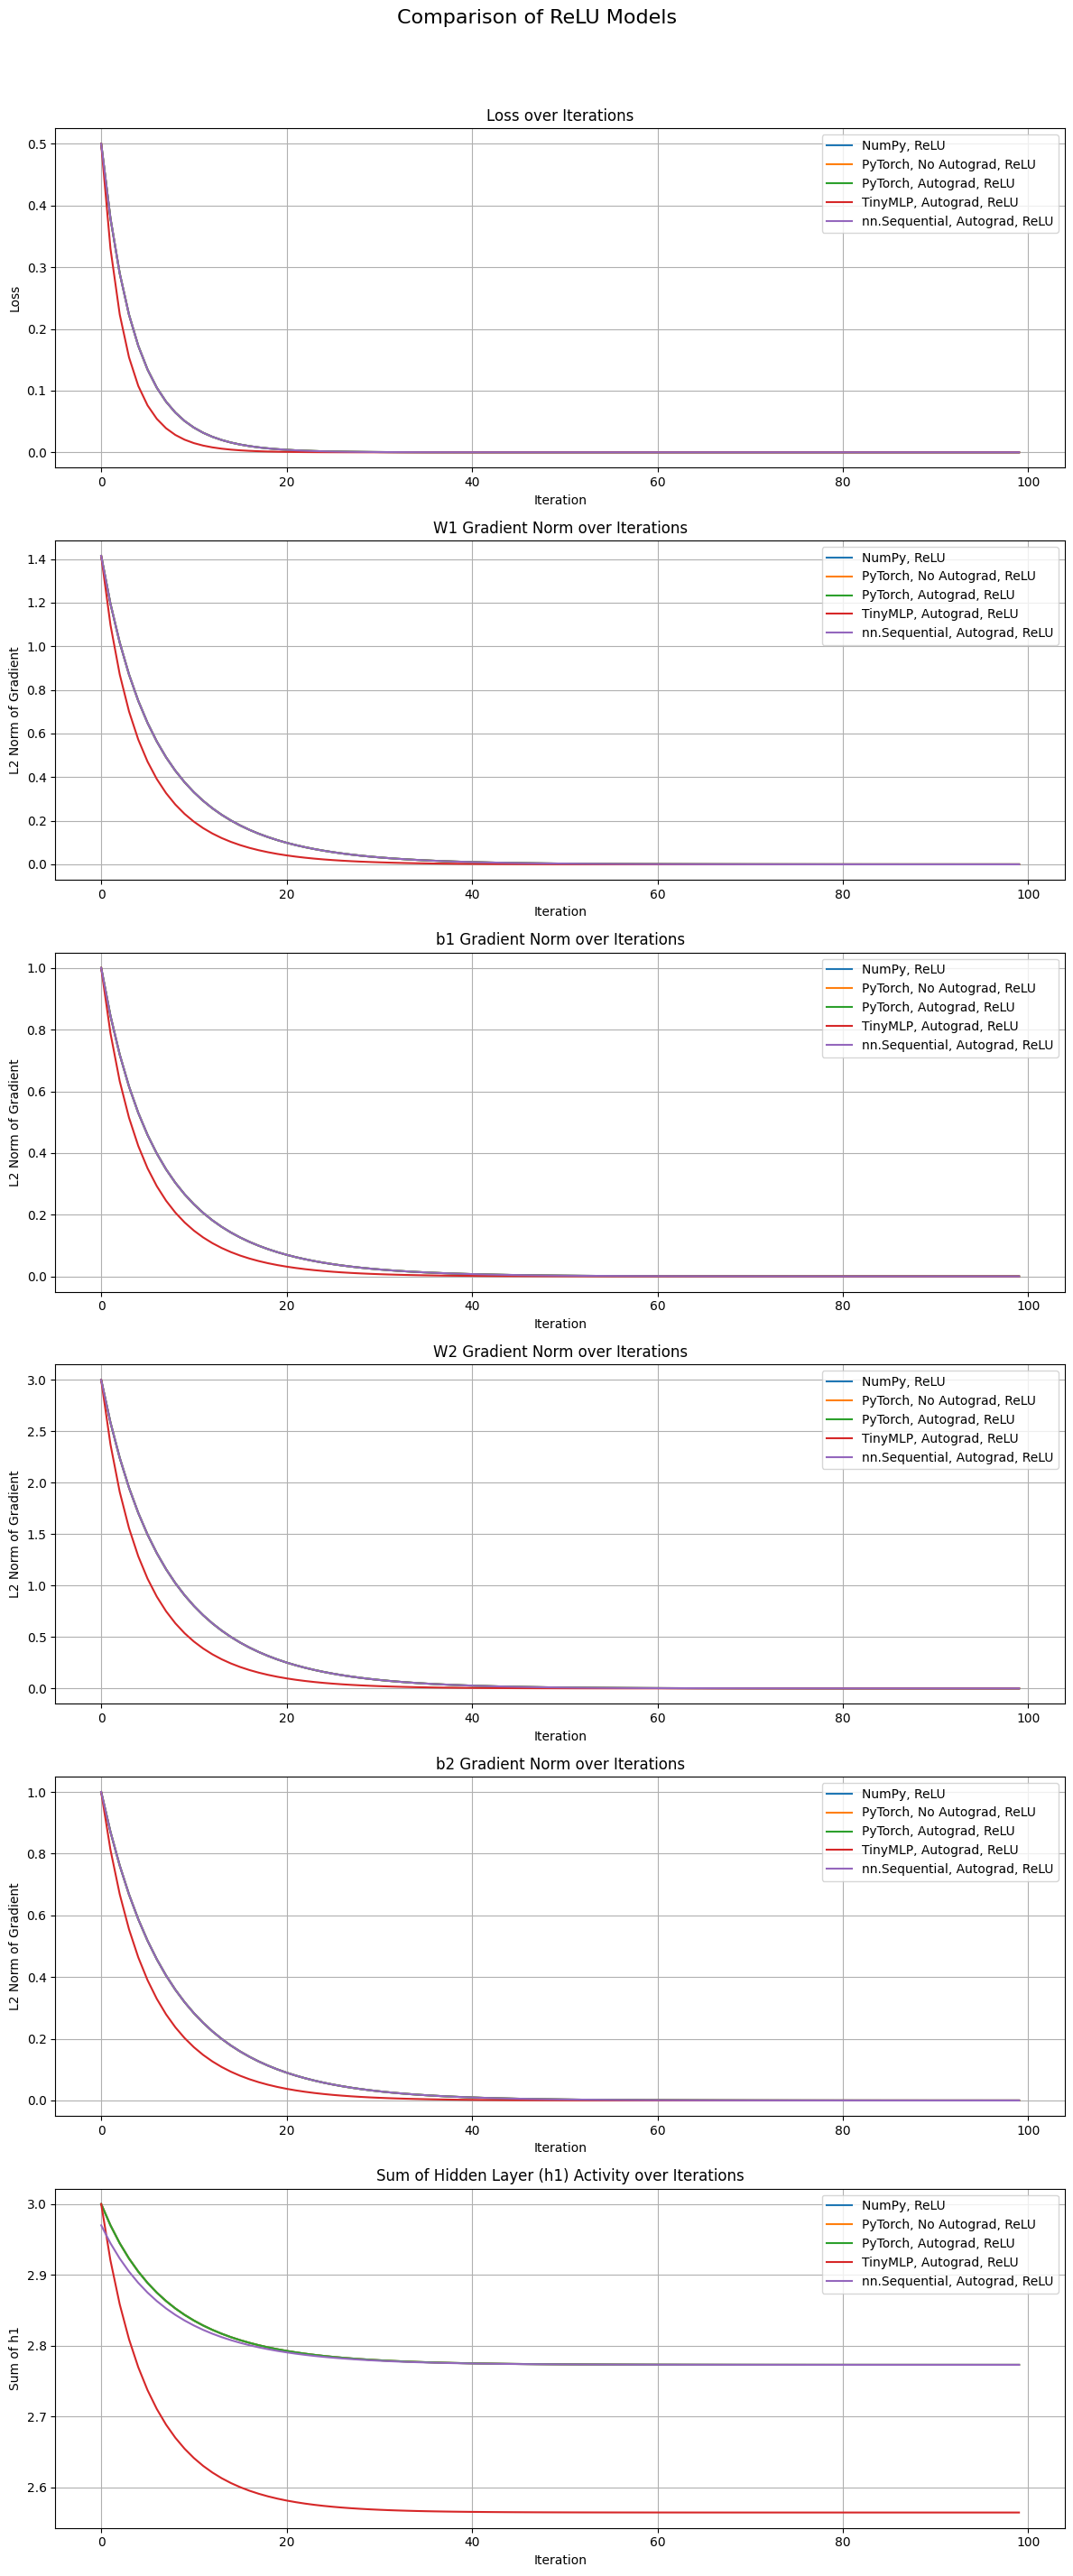

In [5]:
print("Plotting Combined ReLU Results:")
relu_models = [
    {'results': results_numpy_relu, 'label': 'NumPy, ReLU'},
    {'results': results_torch_no_grad_relu, 'label': 'PyTorch, No Autograd, ReLU'},
    {'results': results_torch_autograd_relu, 'label': 'PyTorch, Autograd, ReLU'},
    {'results': results_tinymlp, 'label': 'TinyMLP, Autograd, ReLU'},
    {'results': results_nn_sequential_relu, 'label': 'nn.Sequential, Autograd, ReLU'}
]
plot_comparison_metrics(relu_models, "Comparison of ReLU Models")

Plotting Combined Sigmoid Results:


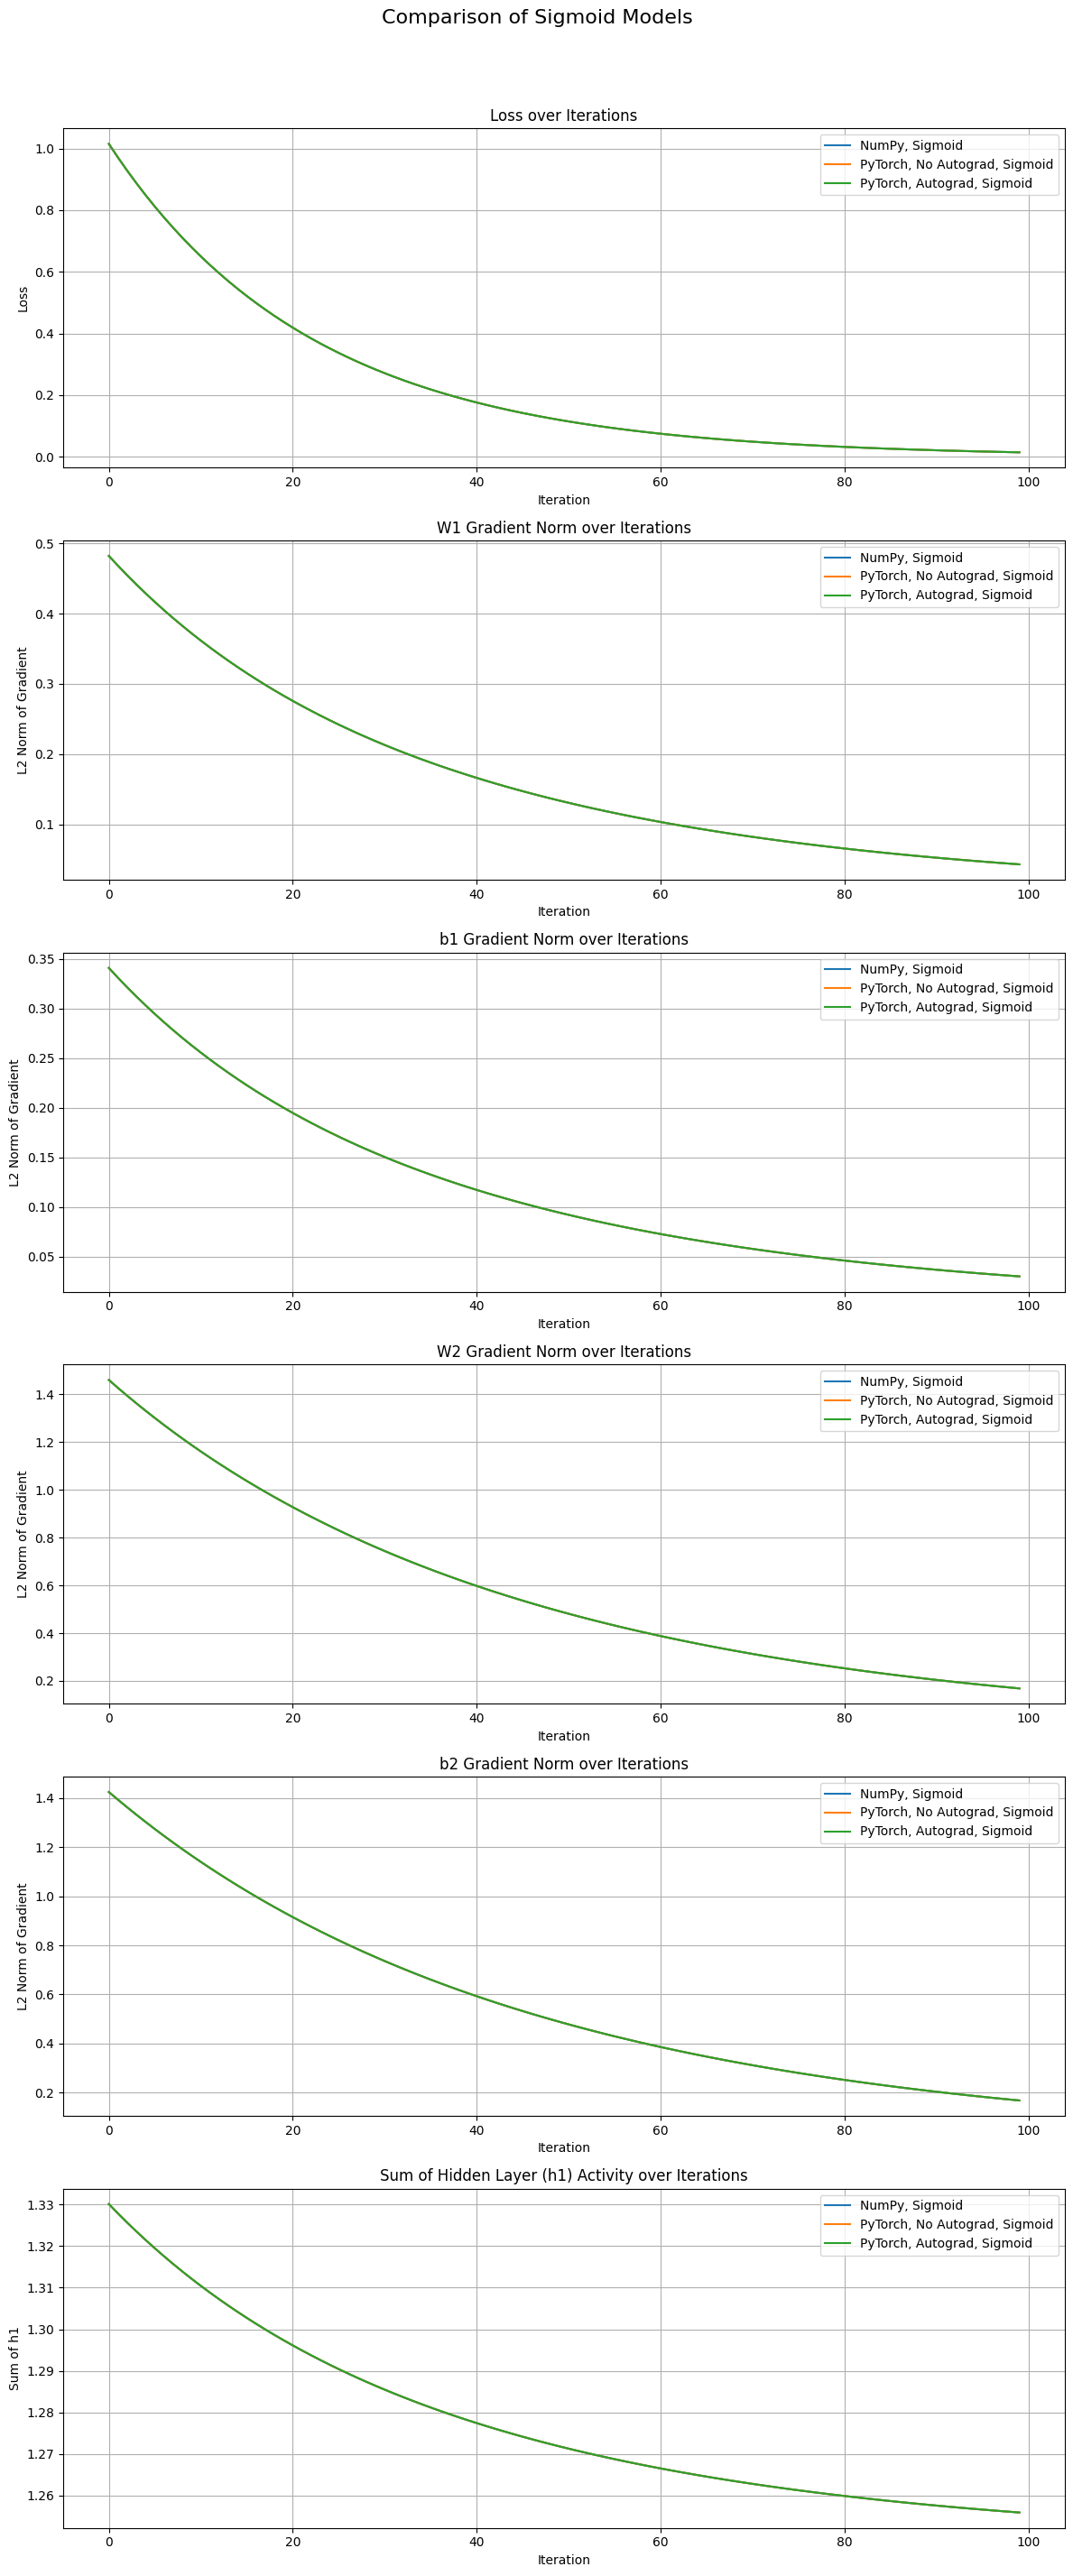

In [6]:
print("Plotting Combined Sigmoid Results:")
sigmoid_models = [
    {'results': results_numpy_sigmoid, 'label': 'NumPy, Sigmoid'},
    {'results': results_torch_no_grad_sigmoid, 'label': 'PyTorch, No Autograd, Sigmoid'},
    {'results': results_torch_autograd_sigmoid, 'label': 'PyTorch, Autograd, Sigmoid'}
]
plot_comparison_metrics(sigmoid_models, "Comparison of Sigmoid Models")